使用设备: cpu
类别: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy'] (共4类)
训练集: 5301 张, 验证集: 1326 张

方案1：从零训练 ResNet18（随机初始化）
Scratch | Epoch [1/5] | Loss: 0.5200 | Val Acc: 81.45%
Scratch | Epoch [2/5] | Loss: 0.3556 | Val Acc: 58.52%
Scratch | Epoch [3/5] | Loss: 0.2788 | Val Acc: 89.89%
Scratch | Epoch [4/5] | Loss: 0.2260 | Val Acc: 82.13%
Scratch | Epoch [5/5] | Loss: 0.2249 | Val Acc: 93.82%
Scratch 完成！用时 2703.5s, 最佳准确率: 93.82%

从零训练 - 总参数: 11,178,564, 可训练: 11,178,564

方案2：冻结特征提取（仅训练全连接层）
Frozen | Epoch [1/5] | Loss: 0.5277 | Val Acc: 91.55%
Frozen | Epoch [2/5] | Loss: 0.2784 | Val Acc: 93.67%
Frozen | Epoch [3/5] | Loss: 0.2123 | Val Acc: 94.80%
Frozen | Epoch [4/5] | Loss: 0.1871 | Val Acc: 95.17%
Frozen | Epoch [5/5] | Loss: 0.1631 | Val Acc: 95.70%
Frozen 完成！用时 1277.8s, 最佳准确率: 95.70%

冻结特征 - 总参数: 11,178,564, 可训练: 2,052

方案3：微调（解冻 layer4 和分类头）
Fine-tune | Epoch [1/5] | Loss: 0.1535 | Val Acc: 98.87%
Fine-tune | Epoch [2/5] | Loss: 0.0

/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 20174 (\N{CJK UNIFIED IDEOGRAPH-4ECE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 20923 (\N{CJK UNIFIED IDEOGRAPH-51BB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_82/2005180257.py:225: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from current font.
  plt.tight_layout()

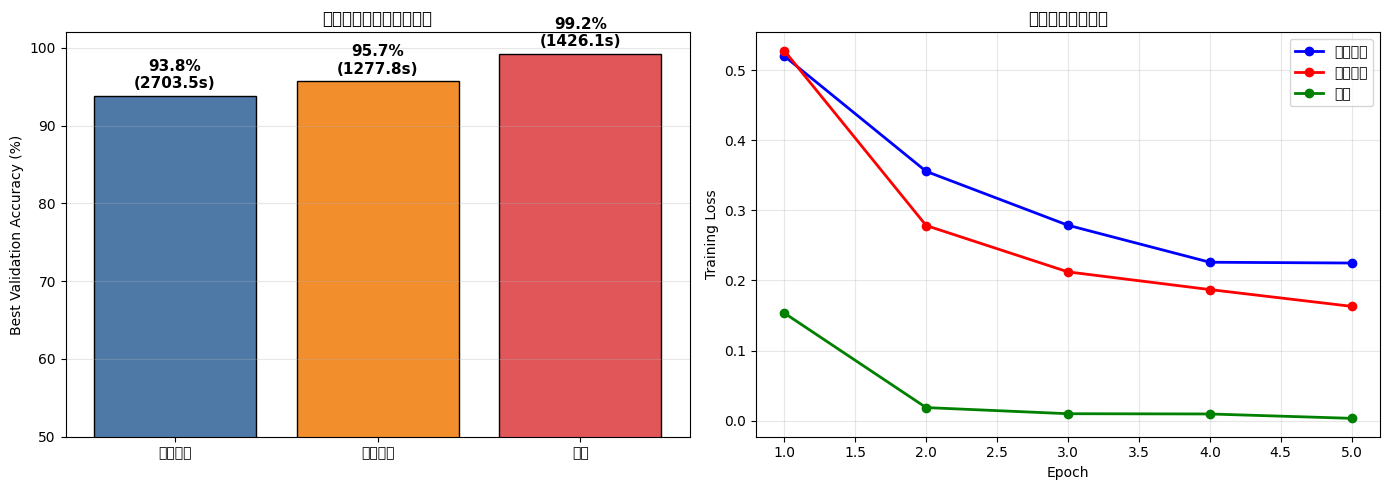


任务D 最终结果总结
方案           最佳准确率        训练时间(s)      可训练参数          
------------------------------------------------------------
从零训练         93.82        2703.5       11,178,564     
冻结特征         95.70        1277.8       2,052          
微调           99.25        1426.1       8,395,780      


In [1]:
# 任务D：综合项目 —— 从零训练 vs 迁移学习大比拼
# 对比三种策略：1) 从零训练 2) 冻结特征提取 3) 微调（解冻 layer4）

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import time
import os

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# ------------------------------
# 1. 数据准备（与任务A/B/C一致）
# ------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

data_dir = './data/PlantVillage'
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"数据目录 {data_dir} 不存在，请先下载PlantVillage数据集")

# 加载完整数据集（训练时用增强）
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

# 划分训练集(80%)和验证集(20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 验证集改用无增强的transform
val_dataset.dataset.transform = val_transform

class_names = full_dataset.classes
num_classes = len(class_names)
print(f"类别: {class_names} (共{num_classes}类)")

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集: {len(train_dataset)} 张, 验证集: {len(val_dataset)} 张")

# ------------------------------
# 2. 通用训练函数（记录Loss、准确率、训练时间）
# ------------------------------
def train_model(model, criterion, optimizer, epochs=5, name=""):
    """训练模型，返回 train_losses, val_accs, elapsed_time"""
    train_losses = []
    val_accs = []
    start_time = time.time()
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # 验证阶段
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        
        val_acc = 100.0 * correct / total
        val_accs.append(val_acc)
        print(f"{name} | Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    elapsed = time.time() - start_time
    best_acc = max(val_accs)
    print(f"{name} 完成！用时 {elapsed:.1f}s, 最佳准确率: {best_acc:.2f}%\n")
    return train_losses, val_accs, elapsed

# ------------------------------
# 3. 方案1：从零训练（随机初始化，训练所有参数）
# ------------------------------
print("\n" + "="*50)
print("方案1：从零训练 ResNet18（随机初始化）")
print("="*50)

model_scratch = models.resnet18(weights=None)  # 不加载预训练权重
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, num_classes)
model_scratch = model_scratch.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

loss_scratch, acc_scratch, time_scratch = train_model(
    model_scratch, criterion, optimizer_scratch, epochs=5, name="Scratch"
)

# 统计参数量
total_params_scratch = sum(p.numel() for p in model_scratch.parameters())
trainable_scratch = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f"从零训练 - 总参数: {total_params_scratch:,}, 可训练: {trainable_scratch:,}")

# ------------------------------
# 4. 方案2：冻结特征提取（仅训练分类头）
# ------------------------------
print("\n" + "="*50)
print("方案2：冻结特征提取（仅训练全连接层）")
print("="*50)

model_frozen = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# 冻结所有卷积层参数
for param in model_frozen.parameters():
    param.requires_grad = False
# 替换分类头（新层默认 requires_grad=True）
model_frozen.fc = nn.Linear(model_frozen.fc.in_features, num_classes)
model_frozen = model_frozen.to(device)

# 只优化分类头参数
optimizer_frozen = optim.Adam(model_frozen.fc.parameters(), lr=0.001)

loss_frozen, acc_frozen, time_frozen = train_model(
    model_frozen, criterion, optimizer_frozen, epochs=5, name="Frozen"
)

total_params_frozen = sum(p.numel() for p in model_frozen.parameters())
trainable_frozen = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
print(f"冻结特征 - 总参数: {total_params_frozen:,}, 可训练: {trainable_frozen:,}")

# ------------------------------
# 5. 方案3：微调（解冻 layer4 + 分类头）
# ------------------------------
print("\n" + "="*50)
print("方案3：微调（解冻 layer4 和分类头）")
print("="*50)

model_finetune = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# 冻结所有参数，然后选择性解冻
for name, param in model_finetune.named_parameters():
    if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False
    else:
        param.requires_grad = True
# 确保分类头正确
model_finetune.fc = nn.Linear(model_finetune.fc.in_features, num_classes)
model_finetune = model_finetune.to(device)

# 使用不同学习率：微调层用小学习率，分类头用正常学习率
optimizer_finetune = optim.Adam([
    {'params': model_finetune.layer4.parameters(), 'lr': 0.0001},  # 微调卷积层
    {'params': model_finetune.fc.parameters(), 'lr': 0.001}        # 新分类头
], lr=0.001)  # 默认lr会被上面覆盖

loss_ft, acc_ft, time_ft = train_model(
    model_finetune, criterion, optimizer_finetune, epochs=5, name="Fine-tune"
)

total_params_ft = sum(p.numel() for p in model_finetune.parameters())
trainable_ft = sum(p.numel() for p in model_finetune.parameters() if p.requires_grad)
print(f"微调 - 总参数: {total_params_ft:,}, 可训练: {trainable_ft:,}")

# ------------------------------
# 6. 可视化对比
# ------------------------------
# 6.1 准确率柱状图（带训练时间标注）
labels = ['从零训练', '冻结特征', '微调']
best_accs = [max(acc_scratch), max(acc_frozen), max(acc_ft)]
times = [time_scratch, time_frozen, time_ft]
colors = ['#4e79a7', '#f28e2b', '#e15759']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(labels, best_accs, color=colors, edgecolor='black')
plt.ylabel('Best Validation Accuracy (%)')
plt.title('三种策略最佳准确率对比')
plt.ylim(50, 102)
plt.grid(True, alpha=0.3, axis='y')

# 在柱子上显示准确率 + 训练时间
for bar, acc, t in zip(bars, best_accs, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%\n({t:.1f}s)', ha='center', fontsize=11, fontweight='bold')

# 6.2 Loss曲线对比
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), loss_scratch, 'bo-', label='从零训练', linewidth=2)
plt.plot(range(1, 6), loss_frozen, 'ro-', label='冻结特征', linewidth=2)
plt.plot(range(1, 6), loss_ft, 'go-', label='微调', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('训练损失曲线对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task_d_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------
# 7. 打印总结表格
# ------------------------------
print("\n" + "="*60)
print("任务D 最终结果总结")
print("="*60)
print(f"{'方案':<12} {'最佳准确率':<12} {'训练时间(s)':<12} {'可训练参数':<15}")
print("-"*60)
print(f"{'从零训练':<12} {max(acc_scratch):<12.2f} {time_scratch:<12.1f} {trainable_scratch:<15,}")
print(f"{'冻结特征':<12} {max(acc_frozen):<12.2f} {time_frozen:<12.1f} {trainable_frozen:<15,}")
print(f"{'微调':<12} {max(acc_ft):<12.2f} {time_ft:<12.1f} {trainable_ft:<15,}")